In [1]:
import numpy as np
import pandas as pd
import os
import ms_entropy as me
import itertools


# Standard mapping for column names
standard_mapping = {
    "name": "Name",
    "ion_mode": "Ion Mode",
    "instrument": "Instrument",
    "instrument_type": "Instrument Type",
    "ionization": "Ionization",
    "collision_energy": "Collision Energy",
    "collision_gas": "Collision Gas",
    "sample_inlet": "Sample Inlet",
    "spectrum_type": "Spectrum Type",
    "precursor_type": "Precursor Type",
    "precursormz": "Precursor M/Z",
    "notes": "Notes",
    "inchikey": "InChIKey",
    "smiles": "SMILES",
    "synon": "Synonyms",
    "formula": "Formula",
    "mw": "Molecular Weight",
    "exactmass": "Exact Mass",
    "cas#": "CAS Number",
    "nist#": "NIST Number",
    "db#": "Database ID",
    "comments": "Comments",
    "unique_scan_number": "Unique Scan Number",
    "spectrum_id": "Spectrum ID",
    "num peaks": "Num Peaks"
}

def standardize_col(df):
    """
    Standardizes column names based on the provided mapping.

    Args:
        df (pd.DataFrame): The DataFrame whose column names need to be standardized.

    Returns:
        pd.DataFrame: DataFrame with standardized column names.
    """
    new_columns = []
    for col in df.columns:
        col_lower = col.lower().replace("reference_", "")
        standardized_col = standard_mapping.get(col_lower, col_lower)
        new_columns.append(standardized_col)
    df.columns = new_columns
    return df

def remove_zero_ions(msms):
    """
    Removes zero-intensity ions from an MS/MS spectrum.

    Args:
        msms (numpy.ndarray or float): MS/MS spectrum as a 2D NumPy array.

    Returns:
        numpy.ndarray: Filtered 2D array with non-zero intensities.
    """
    if isinstance(msms, float) or len(msms) == 0:
        return np.nan
    return msms[msms[:, 1] > 0]

def sort_spectrum(msms):
    """
    Sorts MS/MS peaks by m/z value.

    Args:
        msms (numpy.ndarray): 2D numpy array with [m/z, intensity].

    Returns:
        numpy.ndarray: Sorted 2D array.
    """
    if isinstance(msms, float) or len(msms) == 0:
        return np.nan
    return msms[np.argsort(msms[:, 0])]

def read_msp(file_path):
    """
    Parses an MSP file and extracts MS/MS spectra into a structured pandas DataFrame.

    Args:
        file_path (str): Path to the MSP file.

    Returns:
        pd.DataFrame: Parsed MS/MS spectra with metadata.
    """

    spectra = []
    spectrum = {}

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            if not line:
                continue  # Skip empty lines

            # Identify metadata fields
            if ":" in line:
                key, value = line.split(":", 1)
                key, value = key.strip().lower(), value.strip()

                if key == 'name':
                    # Save the previous spectrum before starting a new one
                    if spectrum:
                        spectra.append(spectrum)
                    spectrum = {'name': value, 'peaks': []}  # Start new spectrum entry
                
                else:
                    spectrum[key] = value  # Store metadata fields
            
            # Parse peak data (if line starts with a number, it's peak data)
            elif line[0].isdigit():
                try:
                    m_z, intensity = map(float, line.split()[:2])
                    spectrum['peaks'].append([m_z, intensity])
                except ValueError:
                    continue  # Ignore malformed lines

        # Save the last spectrum
        if spectrum:
            spectra.append(spectrum)

    # Convert spectra list to DataFrame
    df = pd.DataFrame(spectra)

    # Process peaks: Remove zero-intensity ions & sort by m/z
    df['peaks'] = [sort_spectrum(remove_zero_ions(np.array(peak))) for peak in df['peaks']]

    # Standardize column names
    df = standardize_col(df)

    # Convert numeric columns where applicable
    for column in df.columns:
        if column != 'peaks':  # Skip 'peaks' column
            try:
                df[column] = pd.to_numeric(df[column], errors='ignore')
            except:
                pass

    return df


In [2]:
df = pd.read_csv('/Users/ellayoung/Desktop/metabolo_confi_score/parsed_spectra.csv')

/var/folders/xd/3y34jslx1fsf1k1pd0bz8w3r0000gn/T/ipykernel_6669/446800534.py:1: DtypeWarning: Columns (11,28,29,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/ellayoung/Desktop/metabolo_confi_score/parsed_spectra.csv')


In [4]:
import json

# Load JSON file
with open('/Users/ellayoung/Desktop/metabolo_confi_score/data/MoNA-export-All_LC-MS-MS_QTOF.json', 'r') as f:
    mona_data = json.load(f)




SyntaxError: invalid character in identifier (2390734535.py, line 8)

In [5]:
# Inspect the first record
print(mona_data[0])

{'compound': [{'kind': 'biological', 'tags': [], 'names': [{'computed': False, 'name': 'Zeatin', 'score': 0.0}], 'molFile': '\n  CDK     01292301102D\n\n 16 17  0  0  0  0  0  0  0  0999 V2000\n   -4.8171    4.9200    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -2.2190    4.9200    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -2.2190    3.4200    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -3.5181    7.1700    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    2.7300   -0.2100    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -2.2200   -1.0800    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -3.5181    5.6700    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.3800    0.4200    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -0.9200    1.1700    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.3800   -1.0800    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -0.9200    2.6700    0.0000 N   0  0  0  0  0  0  0  0  0  0  0  0\n    1.7800    0.9600    0

In [8]:
# Function to parse one entry
def parse_entry(entry):
    # Check if LC-MS/MS
    meta = {m['name'].lower(): m['value'] for m in entry.get('metaData', [])}
    instrument_type = meta.get('instrument type', '').lower()
    ionization_mode = meta.get('ionization mode', '').lower()
    
    if 'lc' not in instrument_type and 'esi' not in instrument_type:
        return None  # skip non-LC-MS
    if 'positive' not in ionization_mode and 'negative' not in ionization_mode:
        return None  # skip unknown ionization
    
    # Parse spectrum
    spectrum_str = entry.get('spectrum', '')
    if not spectrum_str:
        return None
    
    peaks = []
    for peak in spectrum_str.strip().split():
        mz, intensity = peak.split(':')
        peaks.append((float(mz), float(intensity)))
    
    if not peaks:
        return None
    
    return {
        'id': entry.get('id', ''),
        'precursor_mz': meta.get('precursor m/z', None),
        'precursor_type': meta.get('precursor type', None),
        'inchi': next((c['value'] for c in entry.get('compound', [{}])[0].get('metaData', []) if c['name'].lower() == 'inchi'), None),
        'inchikey': next((c['value'] for c in entry.get('compound', [{}])[0].get('metaData', []) if c['name'].lower() == 'inchikey'), None),
        'mz_array': [mz for mz, intensity in peaks],
        'intensity_array': [intensity for mz, intensity in peaks]
    }

# Parse all entries
parsed_spectra = []
for entry in mona_data:
    parsed = parse_entry(entry)
    if parsed:
        parsed_spectra.append(parsed)

print(f"Parsed {len(parsed_spectra)} LC-MS/MS spectra!")


Parsed 47726 LC-MS/MS spectra!


In [9]:
parsed_spectra[0]

{'id': 'VF-NPL-QTOF009997',
 'precursor_mz': '220.1193',
 'precursor_type': '[M+H]+',
 'inchi': 'InChI=1S/C10H13N5O/c1-7(4-16)2-3-11-9-8-10(13-5-12-8)15-6-14-9/h2,5-6,16H,3-4H2,1H3,(H2,11,12,13,14,15)/b7-2+',
 'inchikey': 'UZKQTCBAMSWPJD-FARCUNLSSA-N',
 'mz_array': [41.0399,
  43.0192,
  43.0766,
  55.0301,
  57.0709,
  65.015,
  65.0366,
  67.0302,
  67.0517,
  82.0409,
  92.0251,
  94.0407,
  109.0512,
  119.0354,
  119.1288,
  121.0556,
  136.0619,
  136.1628,
  148.0621],
 'intensity_array': [6.207207,
  49.711712,
  1.986987,
  2.316316,
  1.600601,
  3.496496,
  1.581582,
  6.727728,
  4.393393,
  2.598599,
  16.601602,
  8.375375,
  5.252252,
  100.0,
  4.228228,
  1.025025,
  41.038038,
  1.571572,
  2.447447]}

In [13]:
import numpy as np
import random
import ms_entropy as me

def pick_two_different_compounds(spectra_list):
    while True:
        spec1, spec2 = random.sample(spectra_list, 2)

        ik1 = spec1.get('inchikey')
        ik2 = spec2.get('inchikey')

        if not ik1 or not ik2:
            continue  # Skip if missing InChIKey
        
        if ik1[:14] != ik2[:14]:
            return spec1, spec2


def build_entropy_null(parsed_spectra, n_samples=100000, ms2_tol=0.05):
    null_scores = []

    for _ in range(n_samples):
        # Pick random pair with different InChIKey core
        s1, s2 = pick_two_different_compounds(parsed_spectra)

        # Convert peaks to NumPy arrays
        peaks1 = np.array(list(zip(s1['mz_array'], s1['intensity_array'])), dtype=np.float32)
        peaks2 = np.array(list(zip(s2['mz_array'], s2['intensity_array'])), dtype=np.float32)

        try:
            score = me.calculate_entropy_similarity(peaks1, peaks2, ms2_tolerance_in_da=ms2_tol)
        except Exception:
            # Skip if similarity can't be computed
            continue

        null_scores.append(score)

    return null_scores


In [16]:
null_entropy_scores = build_entropy_null(parsed_spectra, n_samples=50000)


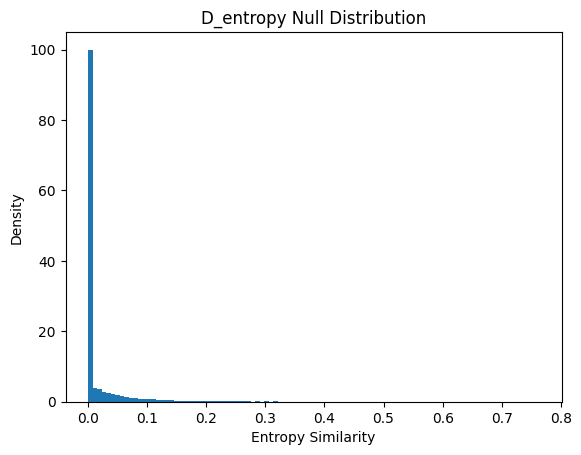

In [17]:
import matplotlib.pyplot as plt

plt.hist(null_entropy_scores, bins=100, density=True)
plt.xlabel('Entropy Similarity')
plt.ylabel('Density')
plt.title('D_entropy Null Distribution')
plt.show()


In [19]:
def compute_entropy_p_value(observed_score, null_scores):
    return np.mean(np.array(null_scores) >= observed_score)


In [20]:
obs_score = 0.42  # from a real query→candidate match
p_val = compute_entropy_p_value(obs_score, null_entropy_scores)
print(f"p-value: {p_val:.6f}")


p-value: 0.002320


In [21]:
cutoff_95 = np.percentile(null_entropy_scores, 95)
print(f"95th percentile entropy similarity cutoff: {cutoff_95:.3f}")


95th percentile entropy similarity cutoff: 0.110


In [22]:
def sample_benchmark_pairs(spectra_list, n_true=500, n_false=500):
    from collections import defaultdict

    # Group spectra by compound (InChIKey core)
    by_core = defaultdict(list)
    for s in spectra_list:
        ik = s.get("inchikey")
        if ik:
            by_core[ik[:14]].append(s)

    # --- True pairs ---
    true_pairs = []
    for specs in by_core.values():
        if len(specs) >= 2:
            pairs = list(itertools.combinations(specs, 2))
            true_pairs.extend(random.sample(pairs, min(len(pairs), n_true - len(true_pairs))))
        if len(true_pairs) >= n_true:
            break

    # --- False pairs ---
    false_pairs = []
    keys = list(by_core.keys())
    while len(false_pairs) < n_false:
        ik1, ik2 = random.sample(keys, 2)
        s1 = random.choice(by_core[ik1])
        s2 = random.choice(by_core[ik2])
        false_pairs.append((s1, s2))

    return true_pairs, false_pairs


In [23]:
def compute_scores_and_labels(pairs, label, ms2_tol=0.05):
    results = []
    for s1, s2 in pairs:
        peaks1 = np.array(list(zip(s1['mz_array'], s1['intensity_array'])), dtype=np.float32)
        peaks2 = np.array(list(zip(s2['mz_array'], s2['intensity_array'])), dtype=np.float32)
        try:
            score = me.calculate_entropy_similarity(peaks1, peaks2, ms2_tolerance_in_da=ms2_tol)
            results.append((score, label))
        except:
            continue  # skip bad pairs
    return results


In [31]:
def benchmark_roc_raw(match_scores, match_labels):
    y_scores = np.array(match_scores)
    y_true = np.array(match_labels)

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"Raw Entropy Similarity (AUC = {roc_auc:.3f})", color='blue')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison')
    plt.grid(True)

    return fpr, tpr, roc_auc


In [32]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

def compute_entropy_p_value(observed_score, null_scores):
    return np.mean(np.array(null_scores) >= observed_score)

def benchmark_roc(match_scores, match_labels, null_entropy_scores):
    # Convert raw scores to p-values
    p_values = [compute_entropy_p_value(s, null_entropy_scores) for s in match_scores]

    # sklearn expects "higher = better", but p-values are "lower = better", so negate
    y_scores = -np.array(p_values)
    y_true = np.array(match_labels)

    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    # (Don't plot here yet; just return values)
    return fpr, tpr, roc_auc



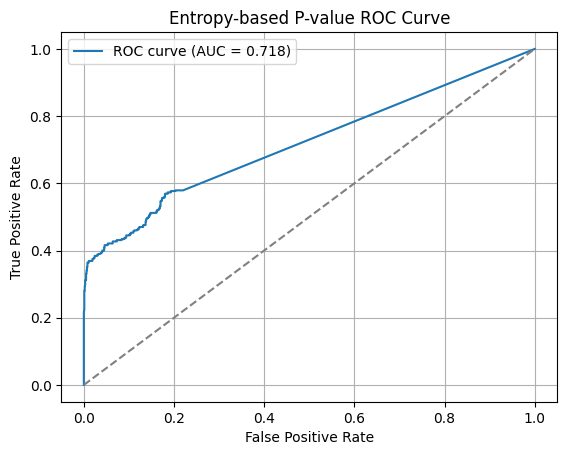

Empirical AUC: 0.7185


In [28]:
true_pairs, false_pairs = sample_benchmark_pairs(parsed_spectra, n_true=1000, n_false=1000)

true_scores = compute_scores_and_labels(true_pairs, label=1)
false_scores = compute_scores_and_labels(false_pairs, label=0)

all_scores = true_scores + false_scores
match_scores = [s for s, label in all_scores]
match_labels = [label for s, label in all_scores]

roc_auc = benchmark_roc(match_scores, match_labels, null_entropy_scores)
print(f"Empirical AUC: {roc_auc:.4f}")


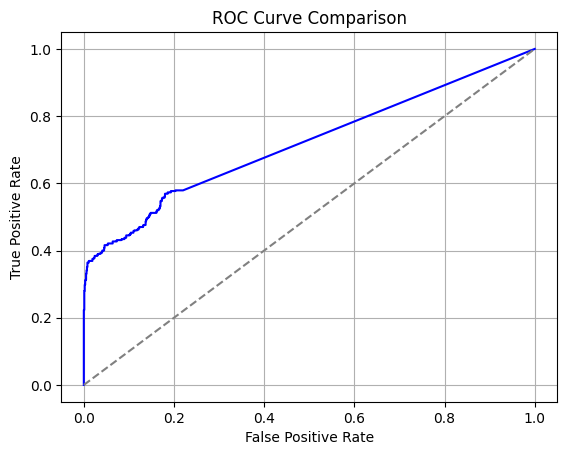

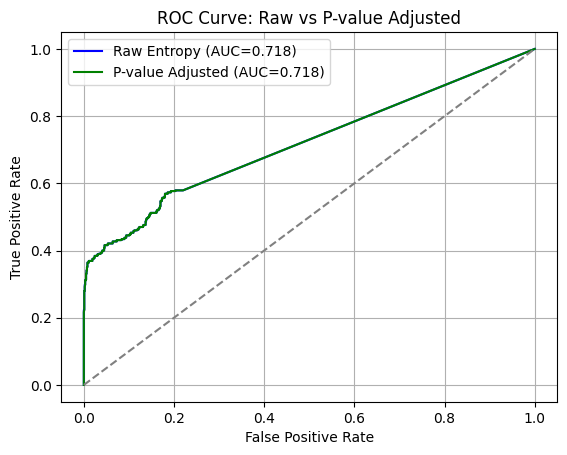

In [33]:
# Benchmark raw entropy similarity
fpr_raw, tpr_raw, auc_raw = benchmark_roc_raw(match_scores, match_labels)

# Benchmark p-value adjusted
fpr_pval, tpr_pval, auc_pval = benchmark_roc(match_scores, match_labels, null_entropy_scores)

# Now overlay them
plt.figure()
plt.plot(fpr_raw, tpr_raw, label=f"Raw Entropy (AUC={auc_raw:.3f})", color='blue')
plt.plot(fpr_pval, tpr_pval, label=f"P-value Adjusted (AUC={auc_pval:.3f})", color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Raw vs P-value Adjusted')
plt.legend()
plt.grid(True)
plt.show()


In [35]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

def benchmark_pr_curves(match_scores, match_labels, null_entropy_scores):
    # Convert scores to p-values
    p_values = [compute_entropy_p_value(s, null_entropy_scores) for s in match_scores]

    # sklearn expects higher score = more likely positive
    y_scores_raw = np.array(match_scores)
    y_scores_pval = -np.array(p_values)
    y_true = np.array(match_labels)

    # Compute PR curves
    precision_raw, recall_raw, _ = precision_recall_curve(y_true, y_scores_raw)
    precision_pval, recall_pval, _ = precision_recall_curve(y_true, y_scores_pval)

    # Compute average precision (area under PR curve)
    ap_raw = average_precision_score(y_true, y_scores_raw)
    ap_pval = average_precision_score(y_true, y_scores_pval)

    # Plot
    plt.figure()
    plt.plot(recall_raw, precision_raw, label=f"Raw Entropy (AP = {ap_raw:.3f})", color="blue")
    plt.plot(recall_pval, precision_pval, label=f"P-value Adjusted (AP = {ap_pval:.3f})", color="green")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve: Raw vs P-value Adjusted")
    plt.legend()
    plt.grid(True)
    plt.show()

    return ap_raw, ap_pval


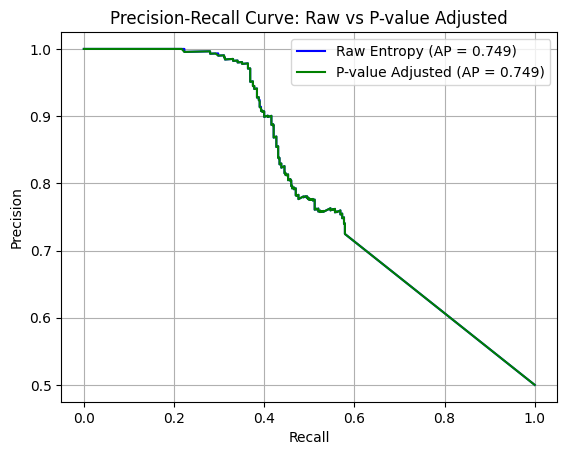

Raw Entropy AP: 0.749
P-value Adjusted AP: 0.749


In [36]:
ap_raw, ap_pval = benchmark_pr_curves(match_scores, match_labels, null_entropy_scores)
print(f"Raw Entropy AP: {ap_raw:.3f}")
print(f"P-value Adjusted AP: {ap_pval:.3f}")


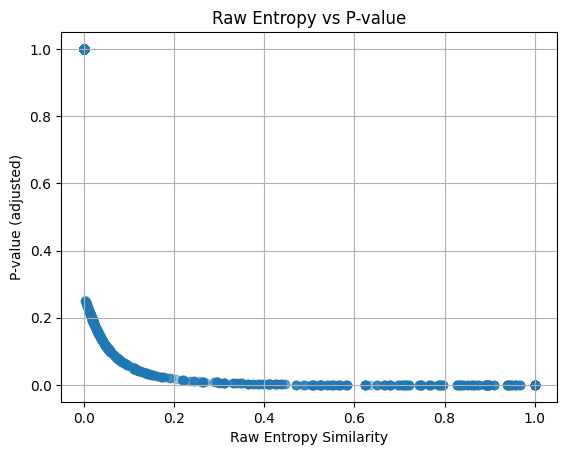

In [37]:
import matplotlib.pyplot as plt

# Compute p-values again
p_values = [compute_entropy_p_value(s, null_entropy_scores) for s in match_scores]

plt.figure()
plt.scatter(match_scores, p_values, alpha=0.4)
plt.xlabel("Raw Entropy Similarity")
plt.ylabel("P-value (adjusted)")
plt.title("Raw Entropy vs P-value")
plt.grid(True)
plt.show()


In [38]:
print("Max entropy score in test:", max(match_scores))
print("Min entropy score in test:", min(match_scores))
print("Range of null_entropy_scores:", min(null_entropy_scores), "to", max(null_entropy_scores))


Max entropy score in test: 1.0
Min entropy score in test: 0.0
Range of null_entropy_scores: 0.0 to 0.763313889503479


In [39]:
from collections import defaultdict
import random

def split_by_inchikey(spectra_list, train_frac=0.7):
    grouped = defaultdict(list)

    for s in spectra_list:
        ik = s.get('inchikey')
        if ik:
            core = ik[:14]
            grouped[core].append(s)

    all_keys = list(grouped.keys())
    random.shuffle(all_keys)

    n_train = int(len(all_keys) * train_frac)
    train_keys = set(all_keys[:n_train])
    test_keys = set(all_keys[n_train:])

    train_set = [s for core in train_keys for s in grouped[core]]
    test_set  = [s for core in test_keys for s in grouped[core]]

    return train_set, test_set


In [40]:
train_spectra, test_spectra = split_by_inchikey(parsed_spectra, train_frac=0.7)


In [41]:
null_entropy_scores = build_entropy_null(train_spectra, n_samples=100000)


In [42]:
true_pairs, false_pairs = sample_benchmark_pairs(test_spectra, n_true=1000, n_false=1000)
true_scores = compute_scores_and_labels(true_pairs, label=1)
false_scores = compute_scores_and_labels(false_pairs, label=0)


In [45]:
match_scores = [s for s, label in true_scores + false_scores]
match_labels = [label for s, label in true_scores + false_scores]


In [46]:
def compute_entropy_p_value(observed_score, null_scores):
    return np.mean(np.array(null_scores) >= observed_score)


In [47]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

def benchmark_roc(match_scores, match_labels, null_entropy_scores):
    # Convert raw scores to p-values
    p_values = [compute_entropy_p_value(s, null_entropy_scores) for s in match_scores]

    # sklearn expects "higher = better", so negate p-values
    y_scores = -np.array(p_values)
    y_true = np.array(match_labels)

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.figure()
    plt.plot(fpr, tpr, label=f"P-value Adjusted (AUC = {roc_auc:.3f})", color='green')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

    return fpr, tpr, roc_auc


In [48]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def benchmark_pr_curves(match_scores, match_labels, null_entropy_scores):
    # Convert scores to p-values
    p_values = [compute_entropy_p_value(s, null_entropy_scores) for s in match_scores]

    y_scores_pval = -np.array(p_values)  # negate: lower p = better
    y_true = np.array(match_labels)

    # PR curve
    precision, recall, _ = precision_recall_curve(y_true, y_scores_pval)
    ap = average_precision_score(y_true, y_scores_pval)

    # Plot
    plt.figure()
    plt.plot(recall, precision, label=f"P-value Adjusted (AP = {ap:.3f})", color="green")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    return precision, recall, ap


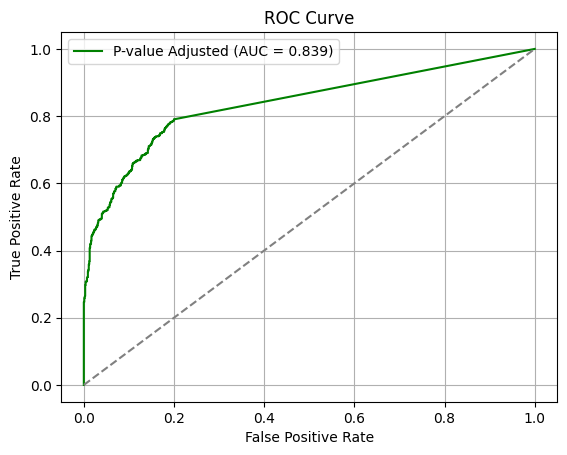

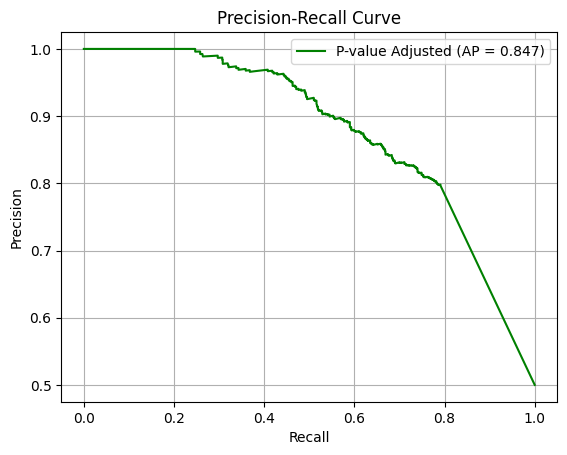

In [49]:
# match_scores = [raw entropy similarities from test set pairs]
# match_labels = [1 if true match, 0 if false match]
# null_entropy_scores = built only from training spectra

fpr, tpr, auc_val = benchmark_roc(match_scores, match_labels, null_entropy_scores)
precision, recall, ap_val = benchmark_pr_curves(match_scores, match_labels, null_entropy_scores)


In [50]:
import matplotlib.pyplot as plt

def compare_score_distributions(null_scores, match_scores):
    plt.figure(figsize=(8, 5))
    plt.hist(null_scores, bins=100, density=True, alpha=0.5, label="Null (random matches)")
    plt.hist(match_scores, bins=100, density=True, alpha=0.5, label="Benchmark (true+false matches)")
    plt.xlabel("Entropy Similarity Score")
    plt.ylabel("Density")
    plt.title("Distribution of Raw Entropy Similarity Scores")
    plt.legend()
    plt.grid(True)
    plt.show()


In [52]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

def compare_roc_raw_vs_pval(match_scores, match_labels, null_entropy_scores):
    # Raw ROC
    y_raw = np.array(match_scores)
    y_true = np.array(match_labels)
    fpr_raw, tpr_raw, _ = roc_curve(y_true, y_raw)
    auc_raw = auc(fpr_raw, tpr_raw)

    # Adjusted p-value ROC
    p_values = [compute_entropy_p_value(s, null_entropy_scores) for s in match_scores]
    y_pval = -np.array(p_values)  # lower p-value = more confident match
    fpr_pval, tpr_pval, _ = roc_curve(y_true, y_pval)
    auc_pval = auc(fpr_pval, tpr_pval)

    # Plot
    plt.figure(figsize=(7, 5))
    plt.plot(fpr_raw, tpr_raw, label=f"Raw Entropy (AUC = {auc_raw:.3f})", color='blue')
    plt.plot(fpr_pval, tpr_pval, label=f"P-value Adjusted (AUC = {auc_pval:.3f})", color='green')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve: Raw vs P-value Adjusted")
    plt.legend()
    plt.grid(True)
    plt.show()

    return auc_raw, auc_pval


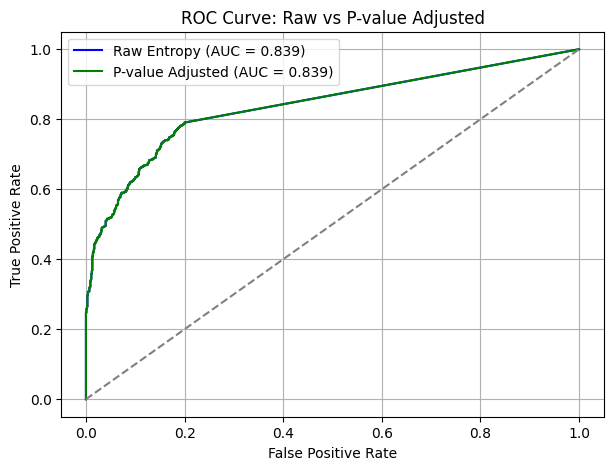

Raw AUC: 0.8386
P-value AUC: 0.8386


In [53]:
auc_raw, auc_pval = compare_roc_raw_vs_pval(match_scores, match_labels, null_entropy_scores)
print(f"Raw AUC: {auc_raw:.4f}")
print(f"P-value AUC: {auc_pval:.4f}")


In [54]:
import numpy as np

def empirical_fdr_curve(scores, labels, thresholds):
    fdrs = []
    recalls = []

    scores = np.array(scores)
    labels = np.array(labels)

    for thresh in thresholds:
        selected = scores >= thresh  # larger = better for raw entropy
        tp = np.sum((labels == 1) & selected)
        fp = np.sum((labels == 0) & selected)

        if tp + fp == 0:
            fdr = 0
            recall = 0
        else:
            fdr = fp / (tp + fp)
            recall = tp / np.sum(labels == 1)

        fdrs.append(fdr)
        recalls.append(recall)

    return fdrs, recalls


In [55]:
def empirical_fdr_curve_pval(p_values, labels, thresholds):
    fdrs = []
    recalls = []

    p_values = np.array(p_values)
    labels = np.array(labels)

    for thresh in thresholds:
        selected = p_values <= thresh  # smaller = better for p-values
        tp = np.sum((labels == 1) & selected)
        fp = np.sum((labels == 0) & selected)

        if tp + fp == 0:
            fdr = 0
            recall = 0
        else:
            fdr = fp / (tp + fp)
            recall = tp / np.sum(labels == 1)

        fdrs.append(fdr)
        recalls.append(recall)

    return fdrs, recalls


In [56]:
import matplotlib.pyplot as plt

def compare_fdr_curves(match_scores, match_labels, null_entropy_scores):
    # Compute p-values
    p_values = [compute_entropy_p_value(s, null_entropy_scores) for s in match_scores]

    # Define thresholds
    raw_thresholds = np.linspace(0, 1, 200)  # entropy similarity scores (higher = better)
    pval_thresholds = np.logspace(-4, 0, 200)  # p-values (lower = better)

    # Compute FDRs
    fdrs_raw, recalls_raw = empirical_fdr_curve(match_scores, match_labels, raw_thresholds)
    fdrs_pval, recalls_pval = empirical_fdr_curve_pval(p_values, match_labels, pval_thresholds)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.plot(raw_thresholds, fdrs_raw, label="Raw Entropy FDR", color='blue')
    plt.plot(pval_thresholds, fdrs_pval, label="P-value Adjusted FDR", color='green')
    plt.xscale('log')
    plt.xlabel("Threshold (Raw Similarity or P-value)")
    plt.ylabel("Empirical FDR")
    plt.title("FDR Curve Comparison")
    plt.axhline(y=0.05, color='red', linestyle='--', label="5% FDR")
    plt.grid(True)
    plt.legend()
    plt.show()


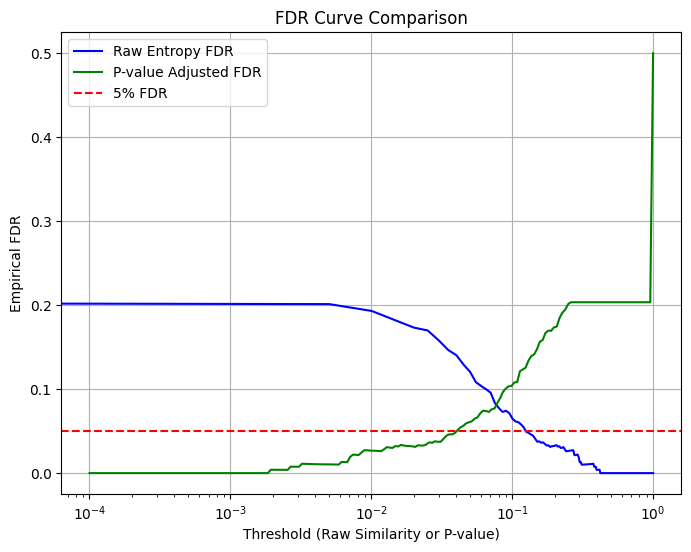

In [57]:
compare_fdr_curves(match_scores, match_labels, null_entropy_scores)


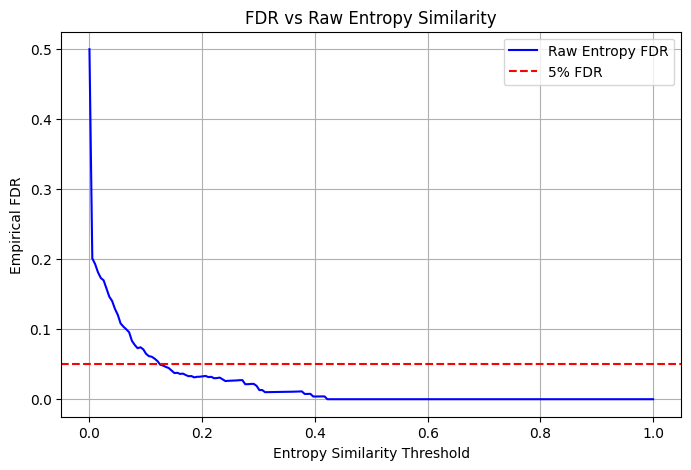

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you already have these:
# - match_scores (raw entropy similarities)
# - match_labels (1 for true, 0 for false)

raw_thresholds = np.linspace(0, 1, 200)
fdrs_raw, _ = empirical_fdr_curve(match_scores, match_labels, raw_thresholds)

plt.figure(figsize=(8, 5))
plt.plot(raw_thresholds, fdrs_raw, color='blue', label='Raw Entropy FDR')
plt.axhline(y=0.05, color='red', linestyle='--', label='5% FDR')
plt.xlabel("Entropy Similarity Threshold")
plt.ylabel("Empirical FDR")
plt.title("FDR vs Raw Entropy Similarity")
plt.legend()
plt.grid(True)
plt.show()


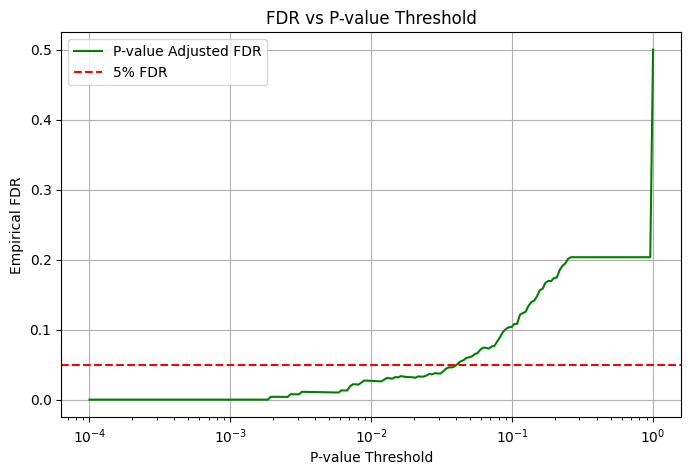

In [60]:
p_values = [compute_entropy_p_value(s, null_entropy_scores) for s in match_scores]
pval_thresholds = np.logspace(-4, 0, 200)
fdrs_pval, _ = empirical_fdr_curve_pval(p_values, match_labels, pval_thresholds)

plt.figure(figsize=(8, 5))
plt.plot(pval_thresholds, fdrs_pval, color='green', label='P-value Adjusted FDR')
plt.axhline(y=0.05, color='red', linestyle='--', label='5% FDR')
plt.xscale('log')
plt.xlabel("P-value Threshold")
plt.ylabel("Empirical FDR")
plt.title("FDR vs P-value Threshold")
plt.legend()
plt.grid(True)
plt.show()


# +-10 mDa null

In [61]:
import numpy as np
import random
import ms_entropy as me
from bisect import bisect_left, bisect_right

def build_mass_matched_null(spectra, mz_tolerance_mda=10, n_samples=100000, ms2_tol=0.05):
    """
    Build a null distribution of entropy similarities between mass-matched but structurally different spectra.
    
    Parameters:
    - spectra: list of parsed spectra dicts (must contain 'precursor_mz', 'inchikey', 'mz_array', 'intensity_array')
    - mz_tolerance_mda: precursor m/z tolerance in milliDaltons (default: ±10 mDa)
    - n_samples: number of random null pairs to sample
    - ms2_tol: MS2 tolerance for entropy similarity (default: 0.05 Da)
    
    Returns:
    - null_entropy_scores: list of entropy similarities for mass-matched random pairs
    """

    # Convert m/z tolerance from mDa to Da
    mz_tolerance_da = mz_tolerance_mda / 1000.0

    # Build a list of (precursor_mz, spectrum) and sort it
    mz_spectra = sorted([(float(s['precursor_mz']), s) for s in spectra if s.get('precursor_mz') and s.get('inchikey')], key=lambda x: x[0])
    precursor_mzs = [mz for mz, s in mz_spectra]

    null_entropy_scores = []
    attempts = 0

    while len(null_entropy_scores) < n_samples and attempts < 10 * n_samples:
        attempts += 1

        # Randomly pick one spectrum
        idx1 = random.randint(0, len(mz_spectra) - 1)
        mz1, spec1 = mz_spectra[idx1]
        ik1 = spec1['inchikey'][:14]

        # Find spectra within m/z tolerance
        low = mz1 - mz_tolerance_da
        high = mz1 + mz_tolerance_da

        left_idx = bisect_left(precursor_mzs, low)
        right_idx = bisect_right(precursor_mzs, high)

        candidates = mz_spectra[left_idx:right_idx]

        # Filter candidates by different InChIKey
        candidates = [s for mz, s in candidates if s['inchikey'][:14] != ik1]

        if not candidates:
            continue  # No valid candidate, skip

        # Randomly select a candidate
        spec2 = random.choice(candidates)

        try:
            # Prepare peak arrays
            peaks1 = np.array(list(zip(spec1['mz_array'], spec1['intensity_array'])), dtype=np.float32)
            peaks2 = np.array(list(zip(spec2['mz_array'], spec2['intensity_array'])), dtype=np.float32)

            # Compute entropy similarity
            score = me.calculate_entropy_similarity(peaks1, peaks2, ms2_tolerance_in_da=ms2_tol)
            null_entropy_scores.append(score)
        except Exception:
            continue  # If calculation fails, skip

    return null_entropy_scores


In [62]:
null_entropy_mass_matched = build_mass_matched_null(train_spectra, mz_tolerance_mda=10, n_samples=100000)


In [63]:
# Raw scores are just match_scores

# Old p-values (random null)
p_values_old = [compute_entropy_p_value(s, null_entropy_scores) for s in match_scores]

# New p-values (mass-matched null)
p_values_mass_matched = [compute_entropy_p_value(s, null_entropy_mass_matched) for s in match_scores]


In [64]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

def compare_all_rocs_prs(match_scores, match_labels, p_values_old, p_values_mass_matched):
    y_true = np.array(match_labels)

    # ROC Curves
    fpr_raw, tpr_raw, _ = roc_curve(y_true, match_scores)
    fpr_old, tpr_old, _ = roc_curve(y_true, -np.array(p_values_old))
    fpr_mass, tpr_mass, _ = roc_curve(y_true, -np.array(p_values_mass_matched))

    auc_raw = auc(fpr_raw, tpr_raw)
    auc_old = auc(fpr_old, tpr_old)
    auc_mass = auc(fpr_mass, tpr_mass)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_raw, tpr_raw, label=f"Raw Entropy (AUC = {auc_raw:.3f})", color='blue')
    plt.plot(fpr_old, tpr_old, label=f"Old p-value Random Null (AUC = {auc_old:.3f})", color='green')
    plt.plot(fpr_mass, tpr_mass, label=f"New p-value Mass-matched Null (AUC = {auc_mass:.3f})", color='red')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

    # PR Curves
    precision_raw, recall_raw, _ = precision_recall_curve(y_true, match_scores)
    precision_old, recall_old, _ = precision_recall_curve(y_true, -np.array(p_values_old))
    precision_mass, recall_mass, _ = precision_recall_curve(y_true, -np.array(p_values_mass_matched))

    ap_raw = average_precision_score(y_true, match_scores)
    ap_old = average_precision_score(y_true, -np.array(p_values_old))
    ap_mass = average_precision_score(y_true, -np.array(p_values_mass_matched))

    plt.figure(figsize=(8, 6))
    plt.plot(recall_raw, precision_raw, label=f"Raw Entropy (AP = {ap_raw:.3f})", color='blue')
    plt.plot(recall_old, precision_old, label=f"Old p-value Random Null (AP = {ap_old:.3f})", color='green')
    plt.plot(recall_mass, precision_mass, label=f"New p-value Mass-matched Null (AP = {ap_mass:.3f})", color='red')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curves Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()


In [65]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

def compare_all_rocs_prs(match_scores, match_labels, p_values_old, p_values_mass_matched):
    y_true = np.array(match_labels)

    # ROC Curves
    fpr_raw, tpr_raw, _ = roc_curve(y_true, match_scores)
    fpr_old, tpr_old, _ = roc_curve(y_true, -np.array(p_values_old))
    fpr_mass, tpr_mass, _ = roc_curve(y_true, -np.array(p_values_mass_matched))

    auc_raw = auc(fpr_raw, tpr_raw)
    auc_old = auc(fpr_old, tpr_old)
    auc_mass = auc(fpr_mass, tpr_mass)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_raw, tpr_raw, label=f"Raw Entropy (AUC = {auc_raw:.3f})", color='blue')
    plt.plot(fpr_old, tpr_old, label=f"Old p-value Random Null (AUC = {auc_old:.3f})", color='green')
    plt.plot(fpr_mass, tpr_mass, label=f"New p-value Mass-matched Null (AUC = {auc_mass:.3f})", color='red')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

    # PR Curves
    precision_raw, recall_raw, _ = precision_recall_curve(y_true, match_scores)
    precision_old, recall_old, _ = precision_recall_curve(y_true, -np.array(p_values_old))
    precision_mass, recall_mass, _ = precision_recall_curve(y_true, -np.array(p_values_mass_matched))

    ap_raw = average_precision_score(y_true, match_scores)
    ap_old = average_precision_score(y_true, -np.array(p_values_old))
    ap_mass = average_precision_score(y_true, -np.array(p_values_mass_matched))

    plt.figure(figsize=(8, 6))
    plt.plot(recall_raw, precision_raw, label=f"Raw Entropy (AP = {ap_raw:.3f})", color='blue')
    plt.plot(recall_old, precision_old, label=f"Old p-value Random Null (AP = {ap_old:.3f})", color='green')
    plt.plot(recall_mass, precision_mass, label=f"New p-value Mass-matched Null (AP = {ap_mass:.3f})", color='red')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curves Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()


In [67]:
def compare_all_fdr_curves(match_scores, match_labels, p_values_old, p_values_mass_matched):
    raw_thresholds = np.linspace(0, 1, 200)
    pval_thresholds = np.logspace(-4, 0, 200)

    fdrs_raw, _ = empirical_fdr_curve(match_scores, match_labels, raw_thresholds)
    fdrs_old, _ = empirical_fdr_curve_pval(p_values_old, match_labels, pval_thresholds)
    fdrs_mass, _ = empirical_fdr_curve_pval(p_values_mass_matched, match_labels, pval_thresholds)

    plt.figure(figsize=(8, 6))
    plt.plot(raw_thresholds, fdrs_raw, label="Raw Entropy FDR", color='blue')
    plt.plot(pval_thresholds, fdrs_old, label="Old p-value FDR (Random Null)", color='green')
    plt.plot(pval_thresholds, fdrs_mass, label="New p-value FDR (Mass-matched Null)", color='red')
    plt.axhline(y=0.05, color='black', linestyle='--', label="5% FDR line")
    plt.xscale('log')
    plt.xlabel("Threshold (Raw Score or p-value)")
    plt.ylabel("Empirical FDR")
    plt.title("Empirical FDR Curves Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()


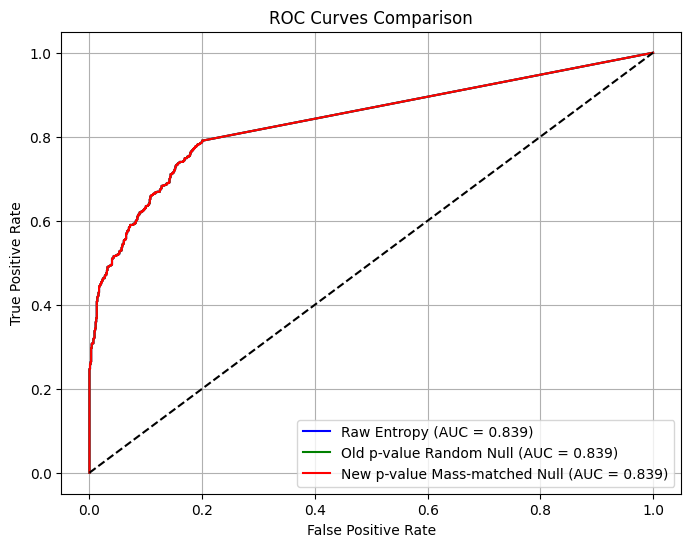

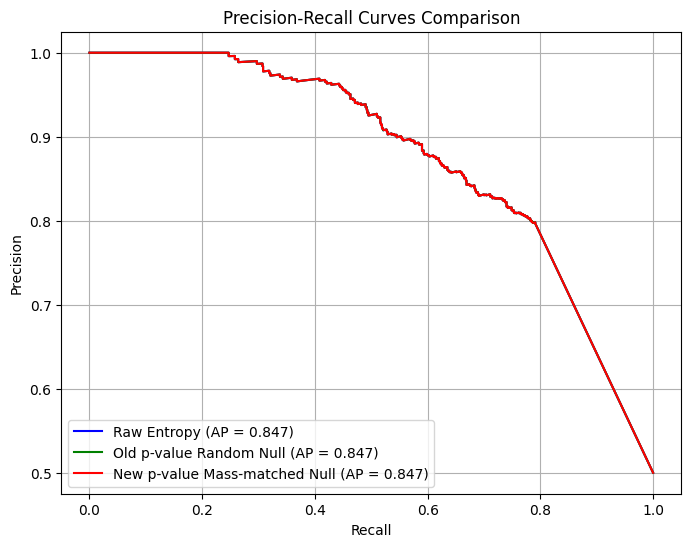

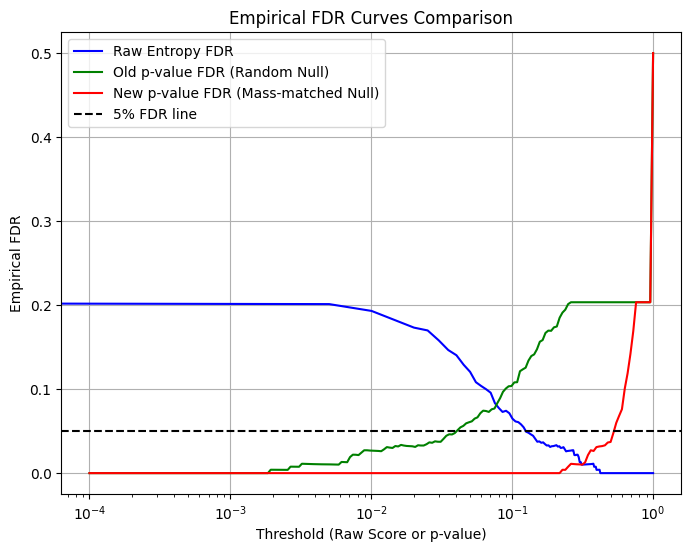

In [68]:
compare_all_rocs_prs(match_scores, match_labels, p_values_old, p_values_mass_matched)
compare_all_fdr_curves(match_scores, match_labels, p_values_old, p_values_mass_matched)


In [69]:
import numpy as np
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

def bootstrap_fdr_auc_curves(
    spectra,                # full test spectra pool
    null_entropy_scores,    # null from random or mass-matched
    n_runs=20,              # number of bootstrap iterations
    n_true=1000,
    n_false=1000,
    raw_score_fn=None,      # function to compute raw score (entropy similarity)
    pval_fn=None            # function to compute p-values from null
):
    aucs_raw = []
    aucs_pval = []
    fdr_curves_raw = []
    fdr_curves_pval = []

    thresholds_raw = np.linspace(0, 1, 100)
    thresholds_pval = np.logspace(-4, 0, 100)

    for i in range(n_runs):
        # Step 1: Sample benchmark pairs
        true_pairs, false_pairs = sample_benchmark_pairs(spectra, n_true=n_true, n_false=n_false)

        # Step 2: Score and label
        all_pairs = true_pairs + false_pairs
        match_labels = [1]*len(true_pairs) + [0]*len(false_pairs)

        match_scores = []
        for s1, s2 in all_pairs:
            peaks1 = np.array(list(zip(s1['mz_array'], s1['intensity_array'])), dtype=np.float32)
            peaks2 = np.array(list(zip(s2['mz_array'], s2['intensity_array'])), dtype=np.float32)
            score = raw_score_fn(peaks1, peaks2)
            match_scores.append(score)

        # Step 3: Compute p-values
        p_values = [pval_fn(s, null_entropy_scores) for s in match_scores]

        # Step 4: Compute AUC
        auc_raw = roc_auc_score(match_labels, match_scores)
        auc_pval = roc_auc_score(match_labels, [-p for p in p_values])
        aucs_raw.append(auc_raw)
        aucs_pval.append(auc_pval)

        # Step 5: Compute FDR curves
        fdr_raw, _ = empirical_fdr_curve(match_scores, match_labels, thresholds_raw)
        fdr_pval, _ = empirical_fdr_curve_pval(p_values, match_labels, thresholds_pval)

        fdr_curves_raw.append(fdr_raw)
        fdr_curves_pval.append(fdr_pval)

    return {
        "thresholds_raw": thresholds_raw,
        "thresholds_pval": thresholds_pval,
        "aucs_raw": aucs_raw,
        "aucs_pval": aucs_pval,
        "fdr_raw": np.array(fdr_curves_raw),
        "fdr_pval": np.array(fdr_curves_pval)
    }


In [70]:
def plot_fdr_with_ci(thresholds, fdr_matrix, label, color):
    mean_fdr = fdr_matrix.mean(axis=0)
    std_fdr = fdr_matrix.std(axis=0)
    ci_upper = mean_fdr + 1.96 * std_fdr / np.sqrt(fdr_matrix.shape[0])
    ci_lower = mean_fdr - 1.96 * std_fdr / np.sqrt(fdr_matrix.shape[0])

    plt.plot(thresholds, mean_fdr, label=f"{label} (mean)", color=color)
    plt.fill_between(thresholds, ci_lower, ci_upper, color=color, alpha=0.2)

def plot_bootstrap_fdr_auc_summary(results):
    # Plot FDR with CI
    plt.figure(figsize=(8,6))
    plot_fdr_with_ci(results["thresholds_raw"], results["fdr_raw"], "Raw Entropy", "blue")
    plot_fdr_with_ci(results["thresholds_pval"], results["fdr_pval"], "P-value Adjusted", "green")
    plt.axhline(y=0.05, linestyle="--", color="black", label="5% FDR")
    plt.xscale('log')
    plt.xlabel("Score Threshold (Raw or P-value)")
    plt.ylabel("Empirical FDR")
    plt.title("Empirical FDR Curve (Bootstrap Mean ± CI)")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Plot AUC distribution
    plt.figure(figsize=(6,4))
    plt.boxplot([results["aucs_raw"], results["aucs_pval"]], labels=["Raw", "P-value"])
    plt.ylabel("ROC AUC")
    plt.title("AUC Distribution Across Bootstraps")
    plt.grid(True)
    plt.show()


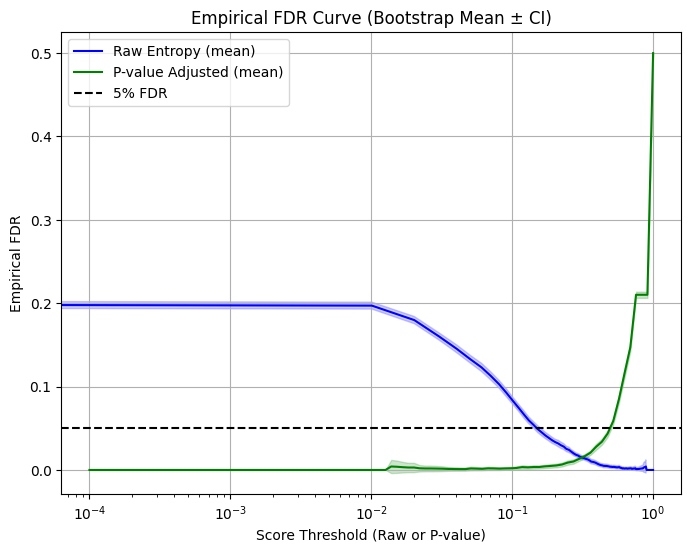

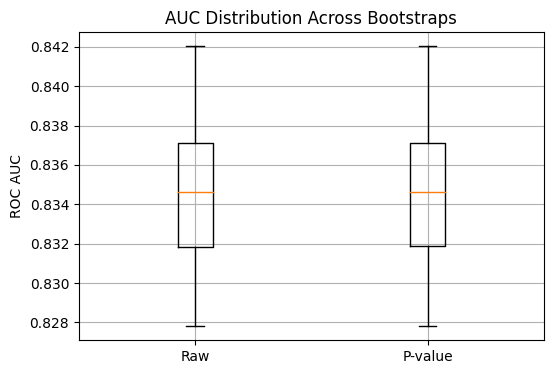

In [71]:
results = bootstrap_fdr_auc_curves(
    spectra=test_spectra,
    null_entropy_scores=null_entropy_mass_matched,
    raw_score_fn=lambda p1, p2: me.calculate_entropy_similarity(p1, p2, ms2_tolerance_in_da=0.05),
    pval_fn=lambda s, null: np.mean(np.array(null) >= s),
    n_runs=20
)

plot_bootstrap_fdr_auc_summary(results)


In [78]:
def count_accepted_below_fdr(fdrs, thresholds, match_scores, match_labels, mode='raw', fdr_cutoff=0.05):
    accepted = []
    for fdr, thresh in zip(fdrs, thresholds):
        if fdr <= fdr_cutoff:
            if mode == 'raw':
                sel = [i for i, s in enumerate(match_scores) if s >= thresh]
            elif mode == 'pval':
                sel = [i for i, s in enumerate(match_scores) if s <= thresh]
            else:
                continue
            tp = sum(match_labels[i] == 1 for i in sel)
            fp = sum(match_labels[i] == 0 for i in sel)
            accepted.append((thresh, tp, fp, len(sel)))
    return accepted[-1] if accepted else (None, 0, 0, 0)


In [79]:
# Raw
thresh_raw, tp_raw, fp_raw, n_raw = count_accepted_below_fdr(fdrs_raw, raw_thresholds, match_scores, match_labels, mode='raw')
# Random-null pval
thresh_old, tp_old, fp_old, n_old = count_accepted_below_fdr(fdrs_old, pval_thresholds, p_values_old, match_labels, mode='pval')
# Mass-matched pval
thresh_mass, tp_mass, fp_mass, n_mass = count_accepted_below_fdr(fdrs_mass, pval_thresholds, p_values_mass_matched, match_labels, mode='pval')
print("🔵 Raw Entropy")
print(f"Accepted {n_raw} matches at threshold ≥ {thresh_raw:.3f} with TP: {tp_raw}, FP: {fp_raw}")

print("🟢 Random Null P-value")
print(f"Accepted {n_old} matches at p ≤ {thresh_old:.3g} with TP: {tp_old}, FP: {fp_old}")

print("🔴 Mass-Matched P-value")
print(f"Accepted {n_mass} matches at p ≤ {thresh_mass:.3g} with TP: {tp_mass}, FP: {fp_mass}")


NameError: name 'fdrs_old' is not defined

# try on MoNA agilent QTOF

In [73]:
import json

# Load JSON file
with open('/Users/ellayoung/Desktop/metabolo_confi_score/data/MoNA-export-All_LC-MS-MS_Agilent_QTOF.json', 'r') as f:
    mona_agilent = json.load(f)




In [74]:

# Parse all entries
parsed_agilent_spectra = []
for entry in mona_agilent:
    parsed = parse_entry(entry)
    if parsed:
        parsed_agilent_spectra.append(parsed)

print(f"Parsed {len(parsed_agilent_spectra)} LC-MS/MS spectra!")


Parsed 23275 LC-MS/MS spectra!


In [75]:
true_pairs, false_pairs = sample_benchmark_pairs(parsed_agilent_spectra, n_true=1000, n_false=1000)


In [76]:
# Combine all pairs
all_pairs = true_pairs + false_pairs
match_labels = [1]*len(true_pairs) + [0]*len(false_pairs)

# Compute raw entropy similarity scores
match_scores = []
for s1, s2 in all_pairs:
    peaks1 = np.array(list(zip(s1['mz_array'], s1['intensity_array'])), dtype=np.float32)
    peaks2 = np.array(list(zip(s2['mz_array'], s2['intensity_array'])), dtype=np.float32)
    score = me.calculate_entropy_similarity(peaks1, peaks2, ms2_tolerance_in_da=0.05)
    match_scores.append(score)

# Compute p-values using mass-matched null
p_values_mass_matched = [compute_entropy_p_value(s, null_entropy_mass_matched) for s in match_scores]


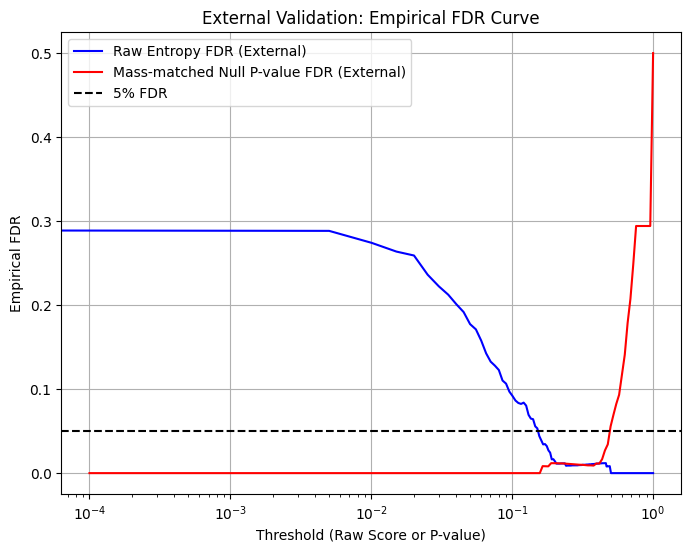

In [77]:
# Generate thresholds
pval_thresholds = np.logspace(-4, 0, 200)
raw_thresholds = np.linspace(0, 1, 200)

# Compute empirical FDR curves
fdrs_raw, _ = empirical_fdr_curve(match_scores, match_labels, raw_thresholds)
fdrs_mass, _ = empirical_fdr_curve_pval(p_values_mass_matched, match_labels, pval_thresholds)

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(raw_thresholds, fdrs_raw, label="Raw Entropy FDR (External)", color='blue')
plt.plot(pval_thresholds, fdrs_mass, label="Mass-matched Null P-value FDR (External)", color='red')
plt.axhline(y=0.05, color='black', linestyle='--', label="5% FDR")
plt.xscale('log')
plt.xlabel("Threshold (Raw Score or P-value)")
plt.ylabel("Empirical FDR")
plt.title("External Validation: Empirical FDR Curve")
plt.grid(True)
plt.legend()
plt.show()
